# Mixed-Operation Composition Analysis

In [3]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("multi_operation_runs")
REPORT_FILES = sorted(DATA_DIR.glob("*.json"))
REPORT_FILES

[PosixPath('multi_operation_runs/Qwen_Qwen3-0.6B_seed13.json'),
 PosixPath('multi_operation_runs/Qwen_Qwen3-0.6B_seed21.json'),
 PosixPath('multi_operation_runs/Qwen_Qwen3-8B_seed13.json'),
 PosixPath('multi_operation_runs/Qwen_Qwen3-8B_seed21.json')]

In [4]:
records = []
for path in REPORT_FILES:
    with path.open() as f:
        payload = json.load(f)
    model_name = path.stem.split("_seed")[0].replace("_", "/", 1)
    seed_str = path.stem.split("_seed")[-1]
    seed = int(seed_str) if seed_str.isdigit() else None
    for split in payload["splits"]:
        steps = split["name"]
        records.append(
            {
                "model": model_name,
                "seed": seed,
                "split": steps,
                "steps": int(steps.split("=")[-1]) if steps.startswith("steps=") else None,
                "accuracy": split["accuracy"],
                "std": split["std"],
                "examples": split["num_examples"],
                "unresolved": split["num_unresolved"],
                "report_path": path.as_posix(),
            }
        )

df = pd.DataFrame(records)
df.sort_values(["model", "seed", "split"], inplace=True)
df.head()

,model,seed,split,steps,accuracy,std,examples,unresolved,report_path
0,Qwen/Qwen3-0.6B,13,add,NaN,0.500,0.501003,250,0,multi_operation_runs/Qwen_Qwen3-0.6B_seed13.json
3,Qwen/Qwen3-0.6B,13,div2,NaN,0.500,0.501003,250,0,multi_operation_runs/Qwen_Qwen3-0.6B_seed13.json
2,Qwen/Qwen3-0.6B,13,mul,NaN,0.500,0.501003,250,0,multi_operation_runs/Qwen_Qwen3-0.6B_seed13.json
4,Qwen/Qwen3-0.6B,13,steps=2,2.0,0.586,0.492795,1000,0,multi_operation_runs/Qwen_Qwen3-0.6B_seed13.json
5,Qwen/Qwen3-0.6B,13,steps=3,3.0,0.522,0.499766,1000,0,multi_operation_runs/Qwen_Qwen3-0.6B_seed13.json


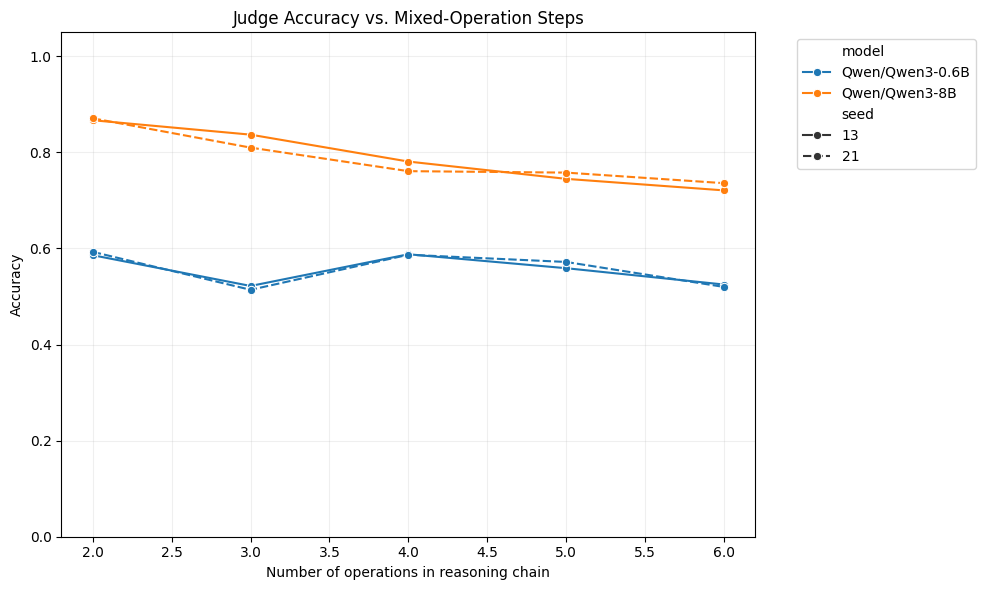

In [5]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df.dropna(subset=["steps"]),
    x="steps",
    y="accuracy",
    hue="model",
    style="seed",
    marker="o",
)
plt.title("Judge Accuracy vs. Mixed-Operation Steps")
plt.ylabel("Accuracy")
plt.xlabel("Number of operations in reasoning chain")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()